# Clustering 

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pickle
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from functions import *
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
with open('processed_data.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

X_scaled = loaded_data['X_scaled']
habit_features = loaded_data['feature_names']
df = loaded_data['original_df']

print(f"Ready to cluster {X_scaled.shape[0]} rows with {len(habit_features)} features.")

Ready to cluster 2000 rows with 8 features.


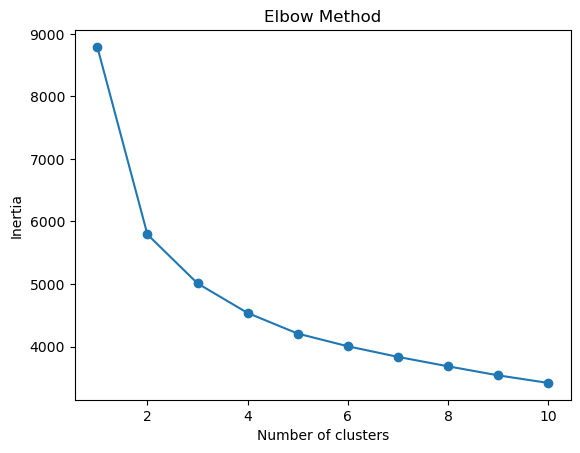

In [18]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [19]:
print("Inertia values:", [round(x, 2) for x in inertia])

Inertia values: [8790.4, 5792.09, 5010.4, 4537.46, 4207.91, 4005.31, 3835.69, 3684.83, 3540.35, 3419.29]


By the elbow curve, the suggested number of clusters could be 3 (or 4).

In [20]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.372
k=3, silhouette score=0.181
k=4, silhouette score=0.174


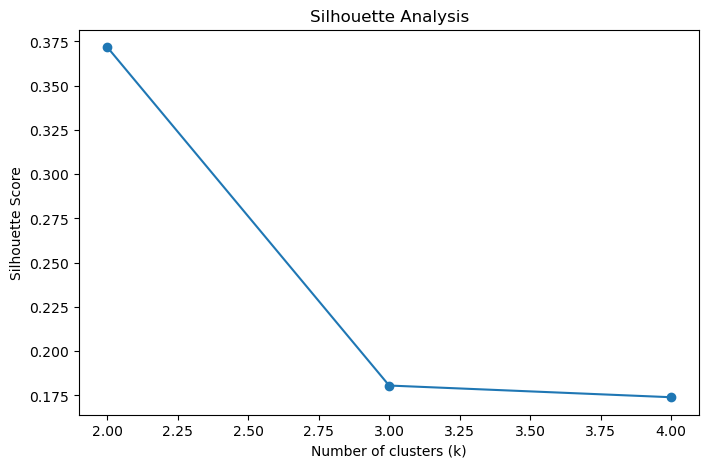

In [21]:
plt.figure(figsize=(8,5))
plt.plot(range(2,5), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

The silhouette score was highest for k=2, suggesting stronger separation with two clusters. However, k=3 was also tested because it may provide a richer behavioral segmentation.

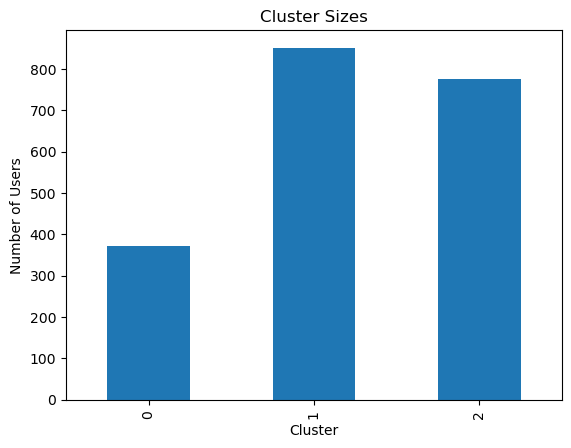

In [22]:
kmeans_3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans_3.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['cluster_kmeans'] = clusters

df.groupby('cluster_kmeans').size().plot(kind='bar')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.show()

Cluster centroids (mean values for each feature):
                work_hours  meetings_count  breaks_taken  after_hours_work  \
cluster_kmeans                                                               
0                11.574531        7.533512      3.672922          0.372654   
1                 7.766686        2.676851      6.505288          0.091657   
2                 9.001598        3.052835      4.157216          0.123711   

                app_switches  sleep_hours  task_completion  isolation_index  
cluster_kmeans                                                               
0                  86.305630     5.539625        66.984638         6.442359  
1                  44.820212     7.280270        87.590376         4.713278  
2                  53.759021     7.123724        78.165799         4.300258  


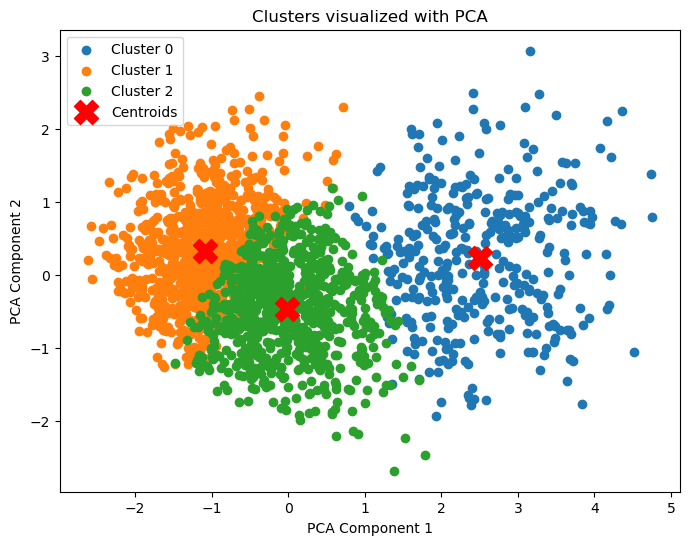

In [23]:
cluster_summary = df.groupby('cluster_kmeans')[habit_features].mean()
print("Cluster centroids (mean values for each feature):")
print(cluster_summary)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transform centroids into PCA space
centroids_pca = pca.transform(kmeans_3.cluster_centers_)

plt.figure(figsize=(8, 6))

# Plot each cluster separately
for cluster in range(3):
    plt.scatter(
        X_pca[clusters == cluster, 0],
        X_pca[clusters == cluster, 1],
        label=f'Cluster {cluster}'
    )

# Plot corrected centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

Cluster profiling was performed by calculating the mean value of each feature for each cluster. The results revealed three distinct behavioral patterns. Cluster 0 showed signs of high workload, frequent meetings, low sleep, and lower task completion, suggesting a more overloaded profile. Cluster 1 presented balanced work hours, more breaks, better sleep, and the highest task completion, indicating a more productive and balanced profile. Cluster 2 represented an intermediate profile, with moderate work intensity and stable performance.